## Transfer Learning and Fine-Tuning for Dog Classification

This notebook implements transfer learning and fine-tuning using pretrained ImageNet models to classify dog images into three classes:

- diego_dog
- lalo_dog
- standford_dogs_subset

In [72]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from torch.optim import Adam
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm

from sklearn.model_selection import train_test_split

In [73]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [74]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [75]:
data_dir = Path("./images")

class_names = ["diego_dog", "lalo_dog", "standford_dogs_subset"]
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

In [76]:
image_extensions = {".jpg", ".jpeg", ".png"}

samples = []

for class_name in class_names:
    class_dir = data_dir / class_name
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            samples.append((str(img_path), class_to_idx[class_name]))

len(samples)

32

In [77]:
paths = [path for path, label in samples]
labels = [label for path, label in samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print(len(train_paths), len(val_paths), len(test_paths))

25 3 4


In [78]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [79]:
class DogDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [80]:
train_data = DogDataset(train_paths, train_labels, train_transform)
val_data = DogDataset(val_paths, val_labels, eval_transform)
test_data = DogDataset(test_paths, test_labels, eval_transform)

batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Funciones de entrenamiento

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for _ in tqdm(range(epochs)):
        model.train()
        train_loss = 0.0
        train_correct = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            pred = output.argmax(dim=1)
            train_correct += (pred == y).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                output = model(x)
                loss = criterion(output, y)

                val_loss += loss.item() * x.size(0)
                pred = output.argmax(dim=1)
                val_correct += (pred == y).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        res['train_loss'].append(train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(val_loss)
        res['val_acc'].append(val_acc)

    return res

## Graficar curvas


In [82]:
def plot_losses(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_loss'], label='train')
    plt.plot(res['val_loss'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_accuracies(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_acc'], label='train')
    plt.plot(res['val_acc'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## Model 1: ResNet18 Transfer Learning

100%|██████████| 10/10 [00:57<00:00,  5.75s/it]


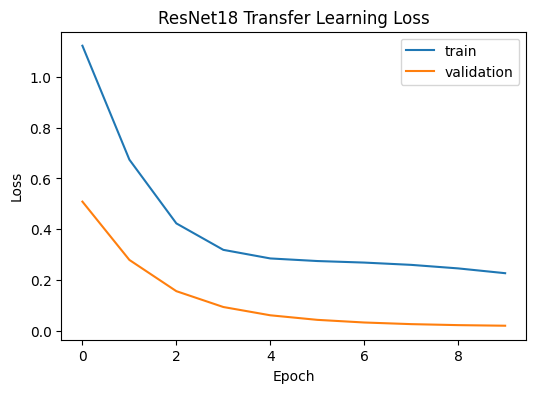

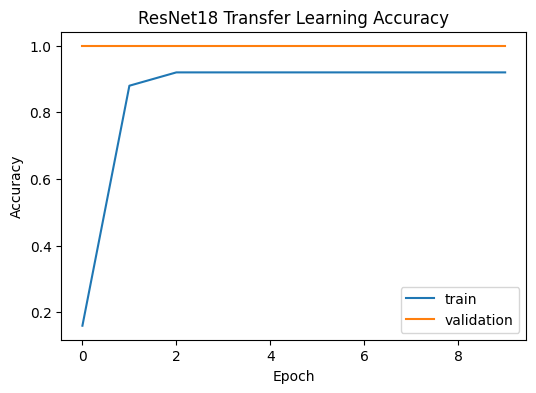

In [83]:
weights = ResNet18_Weights.DEFAULT
model_resnet_tl = resnet18(weights=weights)

for param in model_resnet_tl.parameters():
    param.requires_grad = False

num_features = model_resnet_tl.fc.in_features
model_resnet_tl.fc = nn.Linear(num_features, num_classes)
model_resnet_tl = model_resnet_tl.to(device)

epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_resnet_tl.fc.parameters(), lr=0.001)

resnet_tl_res = train(
    model_resnet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_tl_res, 'ResNet18 Transfer Learning Loss')
plot_accuracies(resnet_tl_res, 'ResNet18 Transfer Learning Accuracy')

## Model 1: ResNet18 Fine-Tuning 

100%|██████████| 10/10 [00:57<00:00,  5.73s/it]


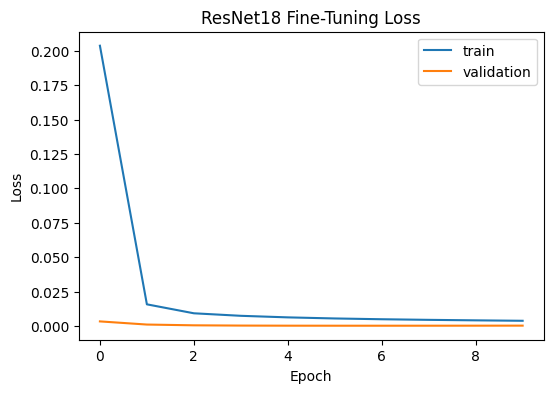

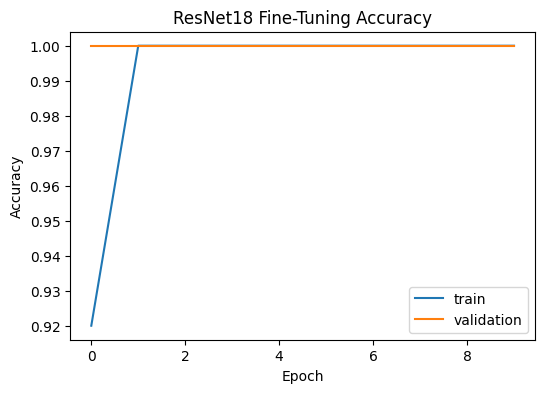

In [84]:
for param in model_resnet_tl.parameters():
    param.requires_grad = False

for param in model_resnet_tl.layer4.parameters():
    param.requires_grad = True

for param in model_resnet_tl.fc.parameters():
    param.requires_grad = True

optimizer = Adam(filter(lambda p: p.requires_grad, model_resnet_tl.parameters()), lr=0.0001)
epochs = 10

resnet_ft_res = train(
    model_resnet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_ft_res, 'ResNet18 Fine-Tuning Loss')
plot_accuracies(resnet_ft_res, 'ResNet18 Fine-Tuning Accuracy')

## Model 2

## Model 2 Finetuning

## Evaluacion y Comparacion

## Reflexion Personal Diego:

## Reflexion Personal Eduardo: